In [ ]:
"""
Copyright (©) CEREMA/DTerOCC/DT/OSECC All rights reserved
auteur : Niels Saura
date de création : Septembre 2026

Script pour entraîner le modèle développé pendant le stage SHREQ à partir du jeu de référence issu du script 1_create_datasets.py.
entrées nécessaires :
- seed
- out_folder
- zh_indivs_fp
- znh_indivs_fp

entrées optionnelles : 
- zh_group_col : nom de la colonne du dataframe des individus zones humides utilisé pour la gestion de l'auto-corrélation spatiale (défaut : "nom")
- znh_autocorrel_grid_size : taille des carreaux utilisés pour la gestion de l'auto-corrélation spatiale des non zones humides en nombre de pixels (défaut : 500)
- train_test_frac
- optim_n_trials : nombre d'itérations de l'optimisation des hyperparams
- season_filter_graphic : export optionnel de l'histogramme du pourcentage de chaque mois conservé pour l'entraînement du modèle
- roc_curve : export optionnel de la courbe ROC du jeu de test, avec AUC et valeur des seuils optimaux précisés dessus
- model_analysis : export de
   - graphique des importances par permutation et informations mutuelles de chaque CP
   - tableau latex des variables les plus corrélées avec chaque CP
   - visualisation de la relation entre chaque CP et la probabilité d'être une zone humide selon le modèle

sortie:
- dictionnaire des paramètres du modèle
- matrice de confusion
- jeux d'entraînement avec plis de validation croisée et jeu de test
"""

'\nCopyright (©) CEREMA/DTerOCC/DT/OSECC All rights reserved\nauteur : Niels Saura\ndate de création : Septembre 2026\n\n\n'

In [ ]:
# Imports

import sys
import os
from pathlib import Path

project_path = Path(__file__).resolve().parent.parent / "lib"
sys.path.append(str(project_path))

import pandas as pd
import os
from os.path import join
import glob
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import random
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
import joblib
from tqdm import tqdm
import time
from sklearn.decomposition import PCA
import shreklib
import torch
torch.no_grad()
from sklearn.model_selection import train_test_split, PredefinedSplit, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import optuna

/usr/local/lib/python3.12/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [ ]:
# parsing des arguments
import argparse

parser = argparse.ArgumentParser()

parser.add_argument("seed", type=int)
parser.add_argument("out_folder")
parser.add_argument("zh_indivs_fp")
parser.add_argument("znh_indivs_fp")
parser.add_argument("--zh_group_col", default="nom")
parser.add_argument("--znh_autocorrel_grid_size", type=int, default=500)
parser.add_argument("--train_test_frac", type=float, default=0.75)
parser.add_argument("--optim_n_trials", type=int, default=15)
parser.add_argument("--season_filter_graphic", type=bool, default=False)
parser.add_argument("--roc_curve", type=bool, default=False)
parser.add_argument("--model_analysis", type=bool, default=False)


args = parser.parse_args()

seed=args.seed

out_folder=args.out_folder

#pickles de dataframe pandas des zones humides et non zones humides, exportés par 1_create_datasets
zh_indivs_fp=args.zh_indivs_fp
znh_indivs_fp=args.znh_indivs_fp

#nom de la colonne du df des zones humides utilisé pour la gestion de l'auto-corrélation spatiale
#dans le split train/test et les trois plis de validation croisée du jeu d'entraînement
zh_group_col=args.zh_group_col

#côté des carreaux utilisés pour la gestion de l'auto-corrélation spatiale des non zones humides
# Attention : exprimé en cellules de la grille de référence
znh_autocorrel_grid_size=args.znh_autocorrel_grid_size

train_test_frac=args.train_test_frac

#nombre d'itération pour l'optimisation des hyperparamètres
optim_n_trials=args.optim_n_trials

#export optionnel de l'histogramme du pourcentage de chaque mois conservé pour l'entraînement du modèle
season_filter_graphic=args.season_filter_graphic

#export optionnel de la courbe ROC du jeu de test, avec AUC et valeur des seuils optimaux précisés dessus.
roc_curve=args.roc_curve

#export de
#   - graphique des importances par permutation et information mutuelle de chaque CP
#   - tableau latex des variables les plus corrélées avec chaque CP
#   - visualisation de la relation entre chaque CP et la probabilité d'être une zone humide selon le modèle
model_analysis=args.model_analysis

In [2]:
# #input

seed=2019

out_folder="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees_propres/modeles/modele_lst"

#pickles de dataframe pandas des zones humides et non zones humides, exportés par 1_create_datasets
zh_indivs_fp="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees_propres/modeles/modele_lst/zh_indivs.pkl"
znh_indivs_fp="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees_propres/modeles/modele_lst/znh_indivs.pkl"

#nom de la colonne du df des zones humides utilisé pour la gestion de l'auto-corrélation spatiale
#dans le split train/test et les trois plis de validation croisée du jeu d'entraînement
zh_group_col="nom"

#côté des carreaux utilisés pour la gestion de l'auto-corrélation spatiale des non zones humides
# Attention : exprimé en cellules de la grille de référence
znh_autocorrel_grid_size=500

train_test_frac=0.75

#nombre d'itération pour l'optimisation des hyperparamètres
optim_n_trials=15

#export optionnel de l'histogramme du pourcentage de chaque mois conservé pour l'entraînement du modèle
season_filter_graphic=True

#export optionnel de la courbe ROC du jeu de test, avec AUC et valeur des seuils optimaux précisés dessus.
roc_curve=True

#export de
#   - graphique des importances par permutation et information mutuelle de chaque CP
#   - tableau latex des variables les plus corrélées avec chaque CP
#   - visualisation de la relation entre chaque CP et la probabilité d'être une zone humide selon le modèle
model_analysis=True

In [ ]:
cell_size=znh_autocorrel_grid_size
rng=np.random.default_rng(seed)
zh=pd.read_pickle(zh_indivs_fp)
znh=pd.read_pickle(znh_indivs_fp)

# splits
zh["classe"]=1
znh["classe"]=0
# split zh groupé selon les noms (pour ne pas avoir la même zone humide dans des splits différents)
grouped=zh.groupby(by="nom")
keys=list(grouped.groups.keys())
rng.shuffle(keys)
cut=int(np.round(len(keys)*train_test_frac))
zh_train=zh[zh["nom"].isin(keys[:cut])]
zh_test=zh[zh["nom"].isin(keys[cut:])]
zh_test.reset_index(drop=True, inplace=True)

znh["tuile_l"]=znh.line//cell_size
znh["tuile_c"]=znh.col//cell_size
cell_grouped=znh.groupby(by=["tuile_l", "tuile_c"])
cell_ids=list(cell_grouped.groups.keys())
np.random.shuffle(cell_ids)
cut=int(np.round(len(cell_ids)*train_test_frac))
cell_ids=np.array(cell_ids)
train_cells=pd.DataFrame({"tuile_l":cell_ids[:cut,0], "tuile_c":cell_ids[:cut,1]})
test_cells=pd.DataFrame({"tuile_l":cell_ids[cut:,0], "tuile_c":cell_ids[cut:,1]})
znh_train=znh.merge(train_cells, on=["tuile_l", "tuile_c"])
znh_test=znh.merge(test_cells, on=["tuile_l", "tuile_c"])

In [9]:
# division du jeu d'entraînement en trois splits
#Les plis sont également groupés par tuiles / zones humides + stratifés par classe + groupés par coordonnées (tous les mois d'un pixel dans le même pli)
zh_train_grouped=zh_train.groupby(by="nom")
zh_train_keys=list(zh_train_grouped.groups.keys())
cut=len(zh_train_keys)//3
np.random.shuffle(zh_train_keys)
zh_train.loc[zh_train.nom.isin(zh_train_keys[:cut]), "pli"]=1
zh_train.loc[zh_train.nom.isin(zh_train_keys[cut:cut*2]), "pli"]=2
zh_train.loc[zh_train.nom.isin(zh_train_keys[cut*2:]), "pli"]=3

znh_train_grouped=znh_train.groupby(by=["tuile_l","tuile_c"])
znh_train_keys=list(znh_train_grouped.groups.keys())
cut=len(znh_train_keys)//3
np.random.shuffle(znh_train_keys)

znh_train.loc[pd.Series(list(zip(znh_train.tuile_l, znh_train.tuile_c))).isin(znh_train_keys[:cut]), "pli"]=1
znh_train.loc[pd.Series(list(zip(znh_train.tuile_l, znh_train.tuile_c))).isin(znh_train_keys[cut:cut*2]), "pli"]=2
znh_train.loc[pd.Series(list(zip(znh_train.tuile_l, znh_train.tuile_c))).isin(znh_train_keys[cut*2:]), "pli"]=3

/tmp/ipykernel_4043012/3480570140.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zh_train.loc[zh_train.nom.isin(zh_train_keys[:cut]), "pli"]=1


In [ ]:
# assemblage des jeux
train=pd.concat([zh_train[[col for col in zh_train.columns if col in znh_train.columns]], znh_train[[col for col in znh_train.columns if col in zh_train.columns]]])
test_dataset=pd.concat([zh_test[[col for col in zh_test.columns if col in znh_test.columns]], znh_test[[col for col in znh_test.columns if col in zh_test.columns]]])
train=train.replace([np.inf, -np.inf], np.nan).dropna()
test_dataset=test_dataset.replace([np.inf, -np.inf], np.nan).dropna()
train.reset_index(drop=True, inplace=True)
test_dataset.reset_index(drop=True, inplace=True)
x_train=train.drop(columns=["line", "col", "classe", "pli", "month"])
y_train=train.classe

x_test=test_dataset.drop(columns=["line", "col", "classe", "month"])
y_test=test_dataset.classe

In [ ]:
# normalisation et ACP
# fonction pour centrer et réduire un df mois par mois
# retourne le df centré et réduit mois par mois + un dictionnaire d'objets shreklib.torchScaler
def monthly_cr(df, months):
    df["month"]=months
    scalers={}
    x_train_cr=[]
    for month, group in df.groupby("month"):
        tens=torch.from_numpy(group.values)
        x_train_scaler=shreklib.torchScaler(tens)
        x_train_cr.append(pd.DataFrame(x_train_scaler.transform(tens), columns=df.columns))
        scalers[month]=x_train_scaler
    x_train_cr=pd.concat(x_train_cr).drop(columns=["month"])
    return x_train_cr.reset_index(drop=True), scalers

In [ ]:
# fonction pour appliquer un dictionnaire de shreklib.torchScaler obtenu via monthly_cr à un dataframe pandas
# retourne le df centré et réduit mois par mois.
def monthly_scale(df, months, scalers):
    df["month"]=months
    df_cr=[]
    for month, group in df.groupby("month"):
        cred_tens=scalers[month].transform(torch.from_numpy(group.values))
        df_cr.append(pd.DataFrame(cred_tens, columns=df.columns))
    df_cr=pd.concat(df_cr).drop(columns=["month"])
    return df_cr.reset_index(drop=True)

In [37]:
x_train_cr, scalers=monthly_cr(x_train.drop(columns=["sin_annuel", "cos_annuel"]), train["month"])

In [38]:
pca=PCA(n_components=0.9)
pca.fit(x_train_cr)
x_train_pcaed=pca.transform(x_train_cr)
x_train_pcaed=pd.DataFrame(x_train_pcaed, columns=[f"CP{i}" for i in range(x_train_pcaed.shape[1])])
x_train_pcaed[["sin_annuel", "cos_annuel"]]=x_train[["sin_annuel", "cos_annuel"]]

In [40]:
x_test_cr=monthly_scale(x_test[x_train.drop(columns=["sin_annuel", "cos_annuel"]).columns], test_dataset["month"], scalers)

/tmp/ipykernel_4043012/1519010409.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["month"]=months


In [41]:
# transformation du jeu de test
x_test_pcaed=pca.transform(x_test_cr)
x_test_pcaed=pd.DataFrame(x_test_pcaed, columns=[f"CP{i}" for i in range(x_test_pcaed.shape[1])])
x_test_pcaed[["sin_annuel", "cos_annuel"]]=x_test[["sin_annuel", "cos_annuel"]]

In [46]:
#filtrage des six mois les plus discriminables pour chaque pixel zone humide
params={"max_depth":20, "n_estimators":300, "min_samples_leaf":7, "min_samples_split":7} # on donne des paramètres par défaut, approximant ceux qu'on a généralement après optim
seasonal_rf=RandomForestClassifier(n_jobs=-1, random_state=seed, class_weight="balanced_subsample", **params)
seasonal_rf.fit(x_train_pcaed, y_train)
train_probas=seasonal_rf.predict_proba(x_train_pcaed)
train.reset_index(drop=True, inplace=True)
train["zh_proba"]=train_probas[:,1]
train_zh=train.loc[train.classe==1]
train_znh=train.loc[train.classe==0]
train_zh_filtered=train_zh.groupby(by=["line", "col"], group_keys=False).apply(lambda g:g.sort_values("zh_proba", ascending=False).head(6))

# tous les mois sont présents
best_months_count=train_zh_filtered.month.value_counts()
initial_months_count=train_zh.month.value_counts()
to_keep=np.concat([train_zh_filtered.index, train_znh.index])
train_filtered=np.concat([train_zh_filtered, train_znh])
x_train_pcaed_filtered=x_train_pcaed.loc[to_keep]
y_train_filtered=y_train[to_keep]

/tmp/ipykernel_4043012/1445426732.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_zh_filtered=train_zh.groupby(by=["line", "col"], group_keys=False).apply(lambda g:g.sort_values("zh_proba", ascending=False).head(6))


AttributeError: 'DataFrame' object has no attribute 'mois'

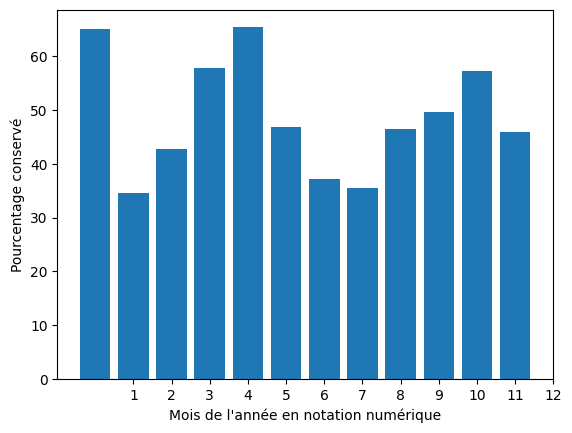

In [93]:
if season_filter_graphic:
    plt.bar(best_months_count.index,(best_months_count/initial_months_count)*100)
    plt.xticks(range(1,13))
    plt.ylabel("Pourcentage conservé")
    plt.xlabel("Mois de l'année en notation numérique")
    plt.savefig(join(out_folder, "pourcentages_mois_zh_conserves_pour_entrainement.png"))

In [49]:
# Optimisation Hyper-Paramètres
train_filtered_ps=PredefinedSplit(train["pli"][to_keep])

In [50]:
def objective(trial):
    max_depth=trial.suggest_int("max_depth", 5,25)
    n_estimators=trial.suggest_int("n_estimators", 150,450)
    min_samples_split=trial.suggest_int("min_samples_split", 5,15)
    min_samples_leaf=trial.suggest_int("min_samples_leaf", 5,15)

    rf=RandomForestClassifier(
        max_depth=max_depth,
        n_estimators=n_estimators,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features="sqrt",
        n_jobs=-1,
        class_weight="balanced_subsample",
        random_state=seed
    )

    score=cross_val_score(rf, x_train_pcaed_filtered, y_train_filtered.values.astype(int), cv=train_filtered_ps, scoring="f1").mean()
    return score



In [51]:
sampler = optuna.samplers.TPESampler(n_startup_trials=5)
study = optuna.create_study(direction="maximize", sampler=sampler)

study.optimize(objective, n_trials=optim_n_trials, show_progress_bar=True)

[I 2026-09-14 12:16:13,878] A new study created in memory with name: no-name-ec315fed-61c9-4983-9796-112eaa6650a1


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-09-14 12:22:44,248] Trial 0 finished with value: 0.9371816515858146 and parameters: {'max_depth': 12, 'n_estimators': 222, 'min_samples_split': 14, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.9371816515858146.
[I 2026-09-14 12:29:51,453] Trial 1 finished with value: 0.9670723335890044 and parameters: {'max_depth': 18, 'n_estimators': 221, 'min_samples_split': 15, 'min_samples_leaf': 12}. Best is trial 1 with value: 0.9670723335890044.
[I 2026-09-14 12:40:10,184] Trial 2 finished with value: 0.9723895635675609 and parameters: {'max_depth': 21, 'n_estimators': 335, 'min_samples_split': 14, 'min_samples_leaf': 7}. Best is trial 2 with value: 0.9723895635675609.
[I 2026-09-14 12:45:39,249] Trial 3 finished with value: 0.9082208640564557 and parameters: {'max_depth': 10, 'n_estimators': 186, 'min_samples_split': 13, 'min_samples_leaf': 5}. Best is trial 2 with value: 0.9723895635675609.
[I 2026-09-14 12:52:16,200] Trial 4 finished with value: 0.9368039035544965 and paramet

KeyboardInterrupt: 

In [52]:
#entraînement
rf_best_zh_months=RandomForestClassifier(n_jobs=-1, random_state=seed, class_weight="balanced_subsample", **study.best_params)
rf_best_zh_months.fit(x_train_pcaed_filtered, y_train_filtered)
rf_affined_train_probas=rf_best_zh_months.predict_proba(x_train_pcaed)
rf_affined_test_probas=rf_best_zh_months.predict_proba(x_test_pcaed)

In [53]:
# ROC / AUC / seuil optim
#on assigne à un pixel la proba de son 6e mois le mieux classé
test_probas_df=pd.DataFrame({"proba":rf_affined_test_probas[:, 1]})
test_probas_df[["line", "col", "classe"]]=test_dataset[["line", "col", "classe"]]
test_probas_sorted=test_probas_df.sort_values(by=["line", "col", "proba"], ascending=[True, True, False])
sixth_hst_proba=test_probas_sorted.groupby(by=["line", "col"]).nth(5)

In [54]:
def get_tvp_tfp(probas, labels):
    # pour faire un calcul de ROC rapide, on quantifie au pourcentage et on utilise np.unique sur lequel on peut ensuite cumsum.
    pourc_probas=np.floor(probas*100).astype(int)
    pourc_probas_pos=pourc_probas[labels.astype(bool)]
    pourc_probas_neg=pourc_probas[~labels.astype(bool)]
    probas_pos, effectif_pos=np.unique(pourc_probas_pos, return_counts=True)
    probas_neg, effectif_neg=np.unique(pourc_probas_neg, return_counts=True)
    # on peut être dans une situation où une probabilité n'existe pas dans le jeu de données, il faut donc prévoir cette possibilité, ce qui est fait ici.
    full_effectif_pos=np.zeros(100)
    full_effectif_neg=np.zeros(100)
    full_effectif_pos[probas_pos]=effectif_pos
    full_effectif_neg[probas_neg]=effectif_neg
    #il faut faire l'effectif cummulé "à l'envers" (le nombre d'individus avec une proba de 0.5 ou plus est la somme des individus avec une proba de 0.5 jusqu'à 1 pas 0 jusqu'à 0.5)
    cum_effectif_pos=np.cumsum(full_effectif_pos[::-1])[::-1]
    cum_effectif_neg=np.cumsum(full_effectif_neg[::-1])[::-1]
    #on divise par les effectifs pertinents, pour obtenir les taux de vrais positifs et faux positifs
    tvp=cum_effectif_pos/len(pourc_probas_pos)
    tfp=cum_effectif_neg/len(pourc_probas_neg)
    return tvp, tfp

In [55]:
tvp6, tfp6 = get_tvp_tfp(sixth_hst_proba.proba.to_numpy(), sixth_hst_proba.classe.to_numpy())
# seuil de proba en pourcentage maximisant tvp-tfp
seuil_optim6=np.argmax(tvp6-tfp6)
seuil_optim6
from scipy.integrate import trapezoid
AUC6=trapezoid(tvp6[::-1], tfp6[::-1])
# ROC classe majoritaire du jeu d'entraînement pour détermination seuil optim
train_probas_df=pd.DataFrame({"proba":rf_affined_train_probas[:, 1]})
train_probas_df[["line", "col", "classe"]]=train[["line", "col", "classe"]]
train_probas_sorted=train_probas_df.sort_values(by=["line", "col", "proba"], ascending=[True, True, False])
train_sixth_hst_proba=train_probas_sorted.groupby(by=["line", "col"]).nth(5)
train_tvp6, train_tfp6 = get_tvp_tfp(train_sixth_hst_proba.proba.to_numpy(), train_sixth_hst_proba.classe.to_numpy())
# seuil de proba en pourcentage maximisant tvp-tfp
train_seuil_optim6=np.argmax(train_tvp6-train_tfp6)
train_seuil_optim6
train_AUC6=trapezoid(train_tvp6[::-1], train_tfp6[::-1])

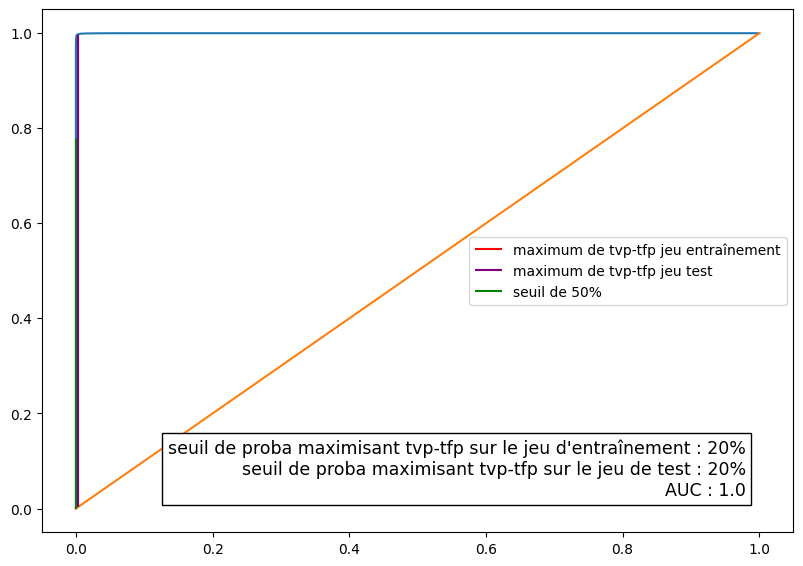

In [56]:
if roc_curve:
    plt.figure(figsize=0.97*np.array([10,7]))
    plt.plot(tfp6, tvp6)
    plt.plot(np.linspace(0,1, 100), np.linspace(0,1,100))
    plt.vlines([tfp6[train_seuil_optim6]],ymin=tfp6[train_seuil_optim6], ymax=tvp6[train_seuil_optim6], color="red", label="maximum de tvp-tfp jeu entraînement")
    plt.vlines([tfp6[seuil_optim6]],ymin=tfp6[seuil_optim6], ymax=tvp6[seuil_optim6], color="purple", label="maximum de tvp-tfp jeu test")
    plt.vlines([tfp6[51]],ymin=tfp6[51], ymax=tvp6[51], color="green", label="seuil de 50%")
    plt.legend(fontsize=10)
    plt.text(0.98, 0.02, f"seuil de proba maximisant tvp-tfp sur le jeu d'entraînement : {train_seuil_optim6}%\nseuil de proba maximisant tvp-tfp sur le jeu de test : {seuil_optim6}%\nAUC : {np.round(AUC6,2)}",
            ha="right",
            va="bottom",
            fontsize=12.5,
            bbox=dict(facecolor="white", edgecolor="black")
        )
    plt.savefig(join(out_folder, "ROC_curve"))

In [ ]:
# validation avec seuil optim
# fonction qui calcule le rappel, la précision et le f1-score de chaque classe d'un array numpy représentant une matrice de confusion
def metrics(cm):
    bien_predit=(cm*np.identity(len(cm))).sum(axis=0)
    rappel=bien_predit/cm.sum(axis=0)
    precision=bien_predit/cm.sum(axis=1)
    f1_score=2*rappel*precision/(rappel+precision)
    return pd.DataFrame({"rappel":rappel, "precision":precision, "f1_score":f1_score})

In [ ]:
# fonction qui prend en entrée un array numpy retourné par metrics et le met sous la forme d'un dataframe pandas plus propre
def pretty_metrics(cm_arr, round=2):
    metrics_table=metrics(cm_arr)
    metrics_table.index=["non zone humide", "zone humide"]
    metrics_table.loc["moyenne"]=metrics_table.values.mean(axis=0)
    return np.round(metrics_table, round)

In [58]:
#on utilise bien le seuil calculé sur le jeu d'entraînement et non de test
sixth_hst_proba.loc[:,"pred_s_optim"]=(sixth_hst_proba.proba>=train_seuil_optim6/100).astype(int)

/tmp/ipykernel_4043012/771169608.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sixth_hst_proba.loc[:,"pred_s_optim"]=(sixth_hst_proba.proba>=train_seuil_optim6/100).astype(int)


In [59]:
cm=pd.crosstab(sixth_hst_proba.pred_s_optim, sixth_hst_proba.classe)
cm_arr=cm.values

In [61]:
cm=cm.rename(columns={0:"nzh", 1:"zh"}, index={0:"nzh", 1:"zh"})

In [62]:
# export modèle
model={
    "scalers":scalers,
    "pca":pca,
    "column_orders":x_train.drop(columns=["sin_annuel", "cos_annuel"]).columns,
    "rf":rf_best_zh_months,
    "proba_seuil_optim":train_seuil_optim6,
    "to_keep":to_keep
}
joblib.dump(model, join(out_folder, "model.pkl"))

['/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees_propres/modeles/modele_lst/model.pkl']

In [104]:
train.to_pickle(join(out_folder, "train_dataset.pkl"))
test_dataset.to_pickle(join(out_folder, "test_dataset.pkl"))

In [63]:
#export métriques
pretty_metrics(cm_arr).to_csv(join(out_folder, "metriques.csv"))
cm.to_csv(join(out_folder, "matrice_de_confusion.csv"))

NameError: name 'cp' is not defined

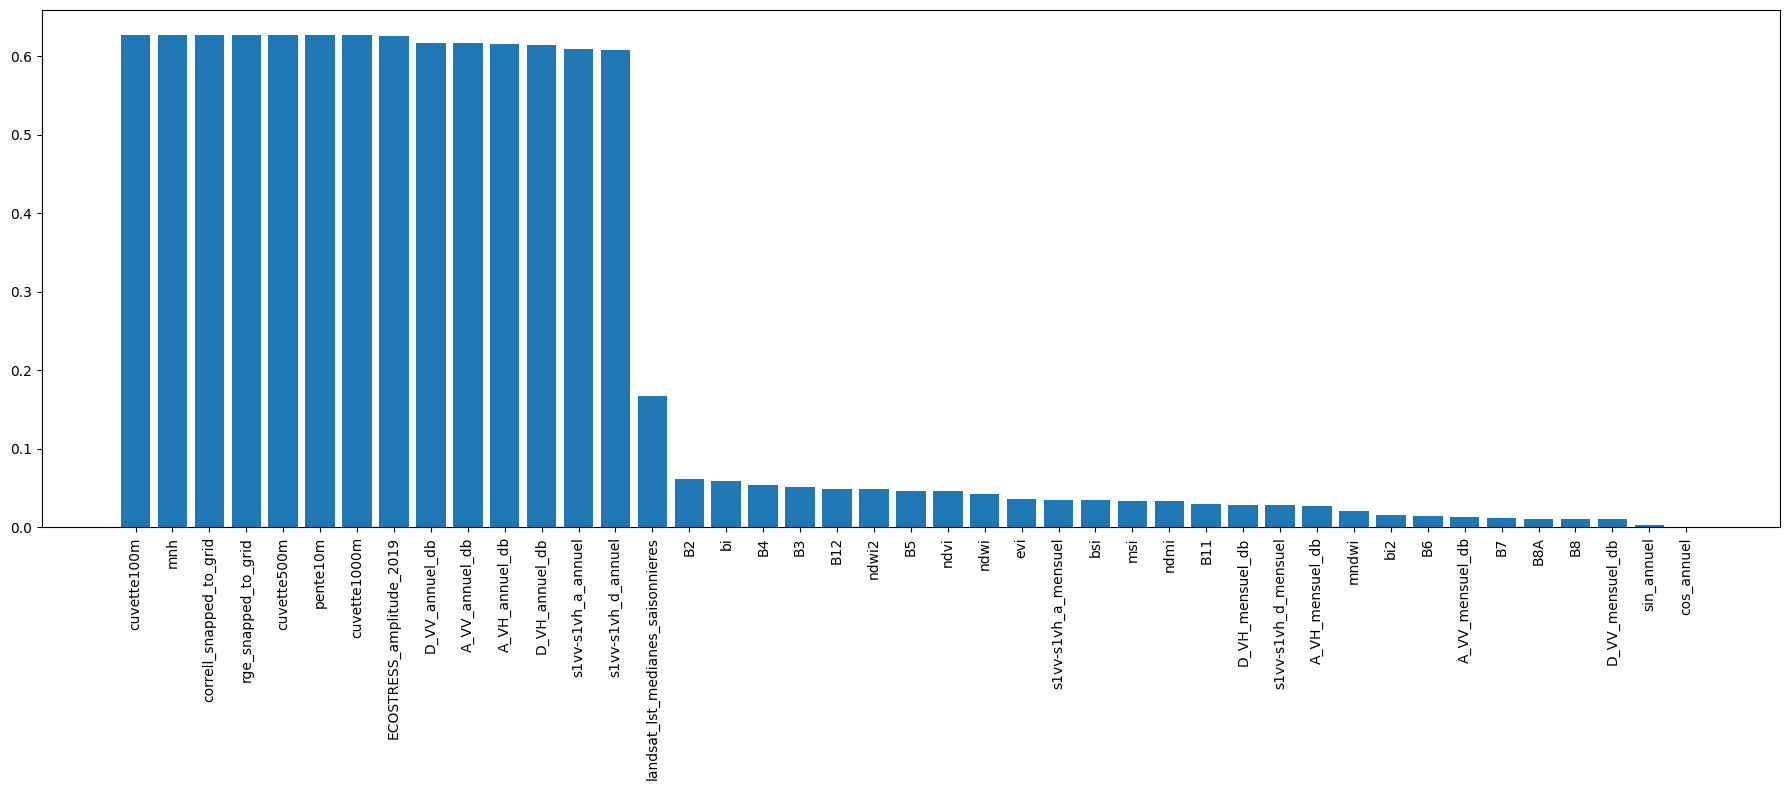

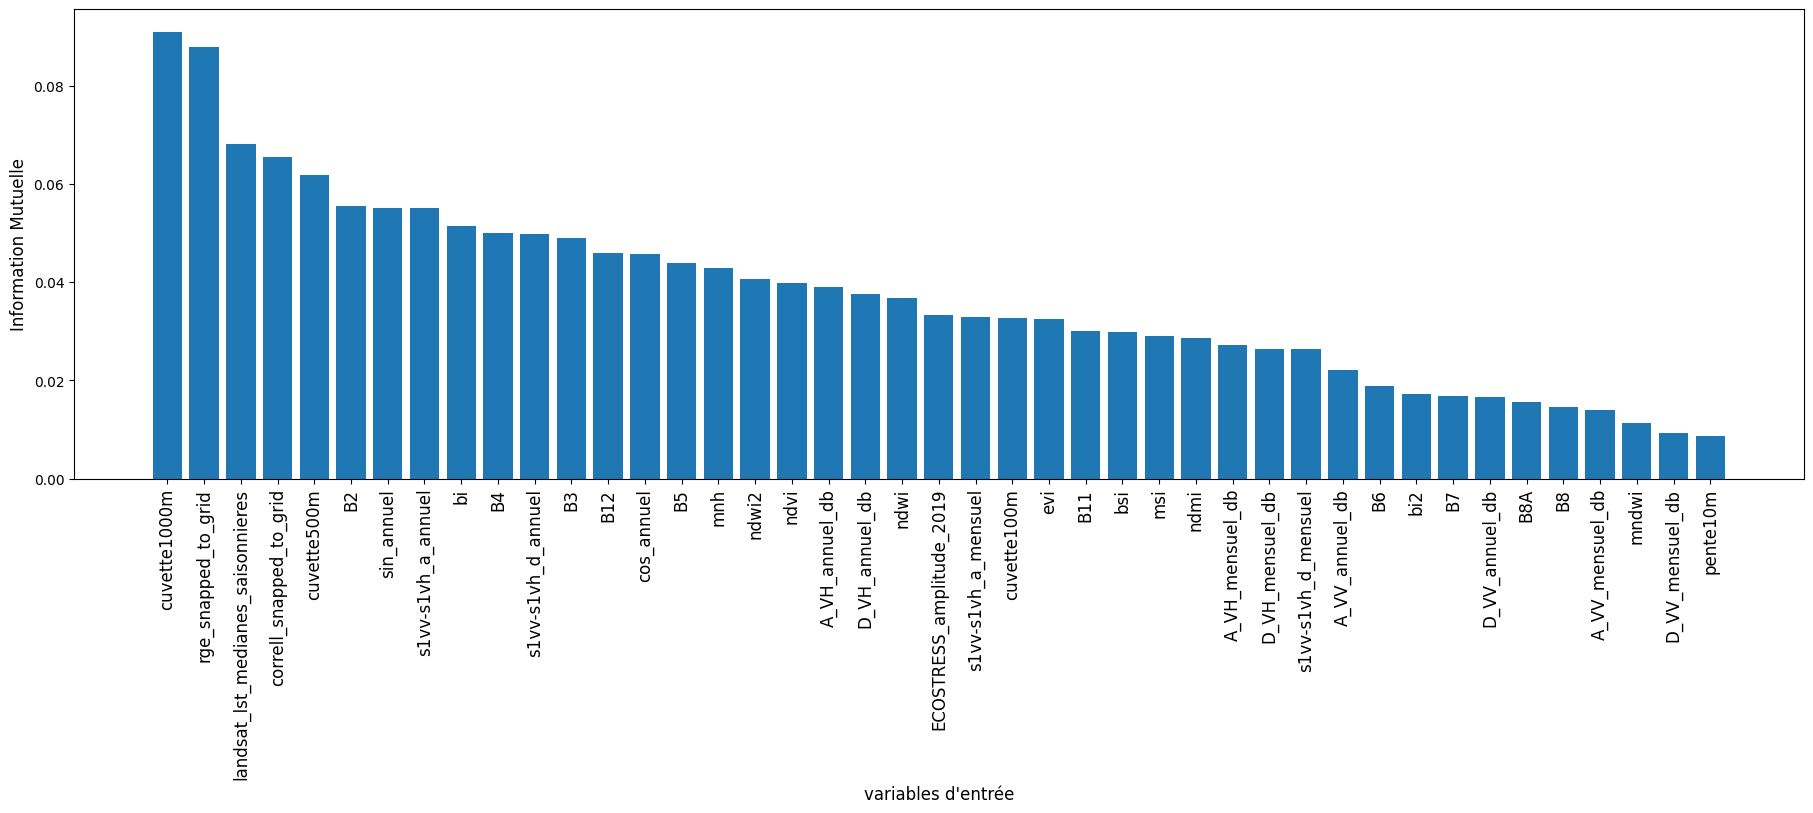

In [ ]:
if model_analysis:
    from sklearn.feature_selection import mutual_info_regression
    slice_plot_df=x_test_pcaed.copy()
    slice_plot_df["proba"]=rf_affined_test_probas[:,1]
    mi = mutual_info_regression(
        x_test_pcaed,
        rf_affined_test_probas[:,1],
        n_jobs=-1
    )
    # information mutuelle des variables brutes et des labels réels
    train_filtered=train.loc[to_keep]
    mi_var_brutes=mutual_info_regression(train_filtered.drop(columns=["line", "col", "month", "classe", "pli", "zh_proba"]), y_train_filtered, n_jobs=-1)
    mi_var_brutes_proba=mutual_info_regression(train.drop(columns=["line", "col", "month", "classe", "pli", "zh_proba"]), rf_affined_train_probas[:,1], n_jobs=-1)
    plt.figure(figsize=(18,8))

    mi_var_brutes_df = pd.DataFrame({
        "var": train_filtered.drop(
            columns=["line", "col", "month", "classe", "pli", "zh_proba"]
        ).columns,
        "im": mi_var_brutes
    })

    mi_var_brutes_df.sort_values(by="im", ascending=False, inplace=True)

    plt.bar(mi_var_brutes_df["var"], mi_var_brutes_df["im"])

    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(join(out_folder, "IM_vars_vs_labels"))

    plt.figure(figsize=(18,8))

    mi_var_brutes_df = pd.DataFrame({
        "var": train.drop(
            columns=["line", "col", "month", "classe", "pli", "zh_proba"]
        ).columns,
        "im": mi_var_brutes_proba
    })

    mi_var_brutes_df.sort_values(by="im", ascending=False, inplace=True)

    plt.bar(mi_var_brutes_df["var"], mi_var_brutes_df["im"])

    plt.xticks(rotation=90, fontsize=12)
    plt.tight_layout()
    plt.xlabel("variables d'entrée", fontsize=12)
    plt.ylabel("Information Mutuelle", fontsize=12)
    plt.savefig(join(out_folder, "IM_vars_vs_probas_zh"))
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import gaussian_kde
    # fonction qui retourne les n_most variables les plus corrélées avec une cp dont le numéro est fourni par le paramètre cp
    def most_correlated(cp, n_most=6):
        slice=corr_df[[cp]].copy()
        slice["abs"]=np.abs(slice[cp])
        return slice.sort_values(by="abs", ascending=False)[cp][:n_most].round(2)
    mi_df=pd.DataFrame({"cp":range(len(mi)), "mi":mi})
    mi_df=mi_df.sort_values(by="mi", ascending=False)
    mi_df["taux_mi"]=(mi_df.mi/mi_df.mi.sum())*100

    ordre_colonnes=x_train.drop(columns=["sin_annuel", "cos_annuel"]).columns.tolist()

    corr=pca.components_.T*np.sqrt(pca.explained_variance_)
    corr_df=pd.DataFrame(corr, columns=[f"CP{i}" for i in range(corr.shape[1])], index=ordre_colonnes)
    mi_df["rang_mi"]=range(1,len(mi_df)+1)
    formatted_corr_vars=lambda col:"\n".join(str(most_correlated(f"CP{col}")).split("\n")[:-1])


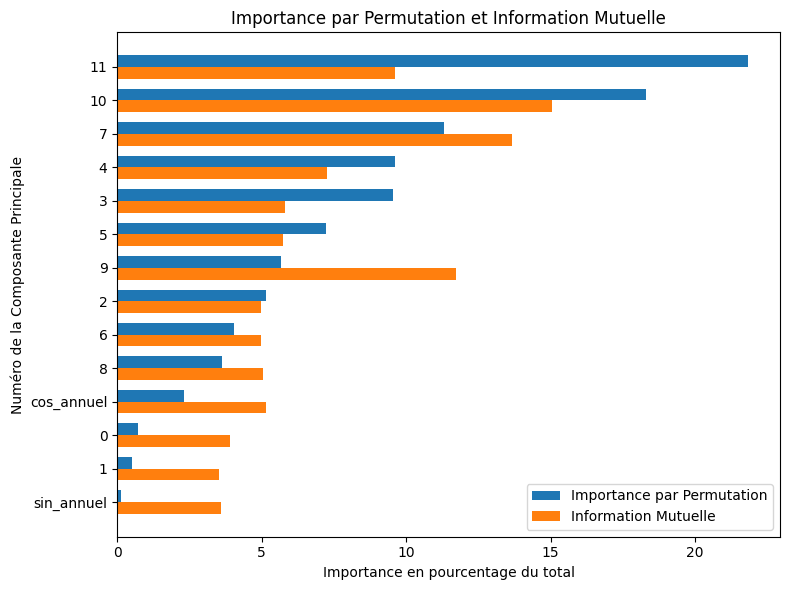

In [ ]:

if model_analysis:    
    # version sans img cp
    # fonction qui exporte une carte de chaleur des probabilités d'être une zone humide en fonction des valeurs d'une cp dont le numéro est fourni avec l'argument col.
    def kde_slice_plot_no_img(col):
        cp0_plot=slice_plot_df[[f"CP{col}", "proba"]].sort_values(by=f"CP{col}")
        cp0_plot_step_sample=cp0_plot.values[np.arange(0, len(cp0_plot), 100)]
        cp0_plot_step_sample.shape, cp0_plot.shape
        clipped=shreklib.percentile_clip(cp0_plot_step_sample)


        X=clipped

        kde = gaussian_kde(X.T)

        # Grille sur laquelle évaluer la densité
        x = np.linspace(X[:, 0].min(), X[:, 0].max(), 200)
        y = np.linspace(X[:, 1].min(), X[:, 1].max(), 200)

        xx, yy = np.meshgrid(x, y)

        # Évaluation de la KDE
        grid = np.vstack([xx.ravel(), yy.ravel()])
        density = kde(grid).reshape(xx.shape)
        density=density/density.sum(axis=0, keepdims=True)

        # Affichage
        fig, ax = plt.subplots(figsize=(7, 6))

        ax.contourf(xx, yy, density, levels=30, cmap="viridis")
        # fig.colorbar(...)

        ax.set_xlabel(f"CP {col}", fontsize=14)
        ax.set_ylabel("taux d'arbres classants en zone humide", fontsize=14)
        ax.set_title(
            f'CP {col} : {int(np.round(mi_df.at[col, "taux_mi"]))}% '
            f"de l'information mutuelle cumulée (rang {mi_df.at[col, "rang_mi"]}/12)", fontsize=14
        )

        ax.text(
            1.02, 0.02,
            "Variables corrélées\n"+formatted_corr_vars(col),
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=14,
            bbox=dict(
                facecolor="white",
                edgecolor="black",
                boxstyle="round,pad=0.4"
            )
        )

        plt.savefig(join(out_folder, f"CP{col}_vs_probas_zh"))
    from concurrent.futures import ProcessPoolExecutor
    with ProcessPoolExecutor(max_workers=32) as executor:
        list(executor.map(kde_slice_plot_no_img, [cp for cp in range(pca.n_components_)]))
    # Importance par permutation
    # On ne conserve que les meilleurs 6 mois pour calculer l'importance par permutation et on remplace le seuil par le seuil optimal
    best_months_test_df=test_dataset[["line", "col", "classe"]].copy()
    best_months_test_df["proba"]=rf_affined_test_probas[:,1]
    best_months_zh_idx=best_months_test_df.sort_values(by="proba").groupby(by=["line", "col"]).head(6)
    to_keep_zh=best_months_zh_idx.loc[best_months_zh_idx.classe==1].index
    to_keep_znh=test_dataset.loc[test_dataset.classe==0].index
    x_test_pcaed_filtered=x_test_pcaed.loc[pd.concat([to_keep_zh.to_series(), to_keep_znh.to_series()])]
    y_test_filtered=y_test.loc[pd.concat([to_keep_zh.to_series(), to_keep_znh.to_series()])]
    from sklearn.inspection import permutation_importance
    from sklearn.metrics import accuracy_score

    threshold = train_seuil_optim6/100

    #fonction pour calculer la précision avec le seuil de probabilité minimal optimisé et non le seuil de 0.5 par défaut
    def threshold_accuracy(estimator, X, y):
        proba = estimator.predict_proba(X)[:, 1]
        y_pred = (proba >= threshold).astype(int)

        return accuracy_score(y, y_pred)
    # importance perm version mois zh affinés
    importances_perm = permutation_importance(
        rf_best_zh_months, x_test_pcaed_filtered, y_test_filtered, n_repeats=5, random_state=seed, n_jobs=1, scoring=threshold_accuracy)
    mi_df=mi_df.sort_values(by="cp")

    mi_df.rename(index={len(mi_df)-2:"sin_annuel", len(mi_df)-1:"cos_annuel"}, inplace=True)
    mi_df["importance_perm"]=importances_perm.importances_mean
    mi_df=mi_df.sort_values(by="importance_perm", ascending=False)
    mi_df["rang_ip"]=range(1, len(mi_df)+1)
    mi_df["taux_ip"]=100*mi_df.importance_perm/mi_df.importance_perm.sum()
    importance1 = mi_df.sort_values(by="cp").taux_ip.values
    importance2 = mi_df.sort_values(by="cp").taux_mi.values
    # Même ordre pour les deux séries
    indices = np.argsort(importance1)


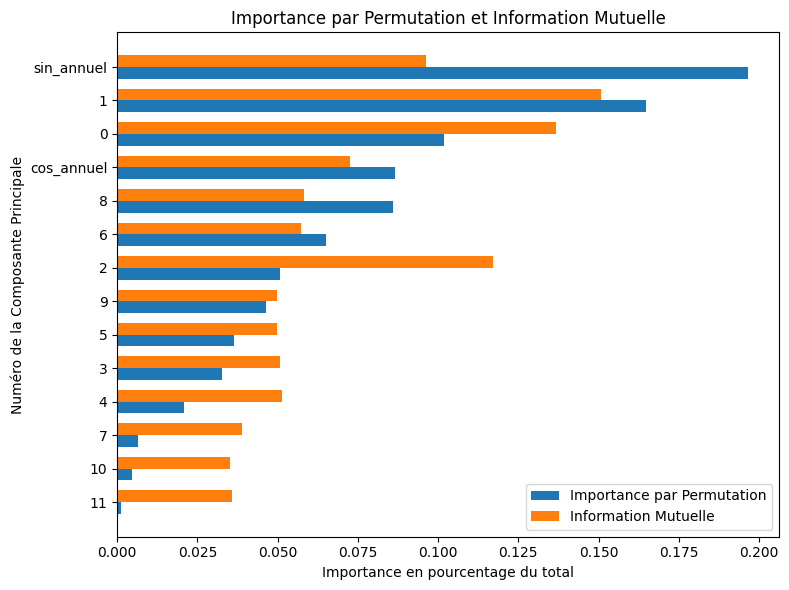

In [ ]:

features_sorted = mi_df.index
importance1_sorted = mi_df.importance_perm
importance2_sorted = mi_df.taux_mi/100

y = np.arange(len(mi_df))
height = 0.35

plt.figure(figsize=(8, 6))

plt.barh(
    y + height / 2,
    importance1_sorted,
    height=height,
    label="Importance par Permutation"
)

plt.barh(
    y - height / 2,
    importance2_sorted,
    height=height,
    label="Information Mutuelle"
)

plt.yticks(y, features_sorted)
plt.gca().invert_yaxis()

plt.xlabel("Importance en pourcentage du total")
plt.ylabel("Numéro de la Composante Principale")
plt.title("Importance par Permutation et Information Mutuelle")
plt.legend()

plt.tight_layout()
plt.savefig(join(out_folder, "features_ip_im"))

# tableau des variables les plus corrélées aux cp

num_var=6
df = pd.DataFrame(
    index=pd.MultiIndex.from_tuples([], names=["CP", "type"]),
    columns=range(1,num_var+1)
)

for cp in range(pca.n_components_):
    mc=most_correlated(f"CP{cp}", n_most=num_var)
    df.loc[(int(cp), "variable"), :] = mc.index
    df.loc[(int(cp), "corrélation"), :] = np.round(mc.values, 2).astype(str)
df.loc[mi_df.loc[~mi_df.index.isin(["sin_annuel", "cos_annuel"])].sort_values(by="rang_ip").cp].to_latex(join(out_folder, "tableau_correlations_vars_cp"), index=True, escape=True, multicolumn=True, multirow=True)

In [99]:
pd.crosstab(test_dataset["month"], test_dataset["classe"], normalize="columns")

classe,0,1
month,,
0,0.083353,0.083334
1,0.083353,0.083334
2,0.083353,0.083331
3,0.083334,0.083334
4,0.083334,0.083334
5,0.083334,0.083334
6,0.083288,0.083334
7,0.083288,0.083334
8,0.083286,0.083334
